Random Forest

RF - PCA

In [1]:
import numpy as np

# Labels
y_train = np.load("y_train_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

# PCA Features
X_train_pca = np.load("X_train_pca.npy")
X_val_pca   = np.load("X_val_pca.npy")
X_test_pca  = np.load("X_test_pca.npy")


Baseline

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_baseline_pca = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_baseline_pca.fit(X_train_pca, y_train)

val_pred  = rf_baseline_pca.predict(X_val_pca)
test_pred = rf_baseline_pca.predict(X_test_pca)

print("Baseline RF + PCA Validation Acc:", accuracy_score(y_val, val_pred))
print("Baseline RF + PCA Test Acc      :", accuracy_score(y_test, test_pred))

Baseline RF + PCA Validation Acc: 0.9246575342465754
Baseline RF + PCA Test Acc      : 0.8108108108108109


Parameter Tuning

In [5]:
param_grid_rf = {
    "n_estimators": [300, 500, 700],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.7, 0.9],
    "class_weight": [None, "balanced"]
}

In [6]:
from sklearn.model_selection import GridSearchCV

grid_rf_pca = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf_pca.fit(X_train_pca, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.7, ...], 'min_samples_leaf': [1, 2], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,700


In [7]:
print("Best Params:", grid_rf_pca.best_params_)
print("Best CV Score:", grid_rf_pca.best_score_)

best_rf_pca = grid_rf_pca.best_estimator_

Best Params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 700}
Best CV Score: 0.8512527233115469


In [8]:
val_acc  = best_rf_pca.score(X_val_pca, y_val)
test_acc = best_rf_pca.score(X_test_pca, y_test)

print("\nTuned RF + PCA Validation Accuracy:", val_acc)
print("Tuned RF + PCA Test Accuracy:", test_acc)


Tuned RF + PCA Validation Accuracy: 0.9246575342465754
Tuned RF + PCA Test Accuracy: 0.8581081081081081


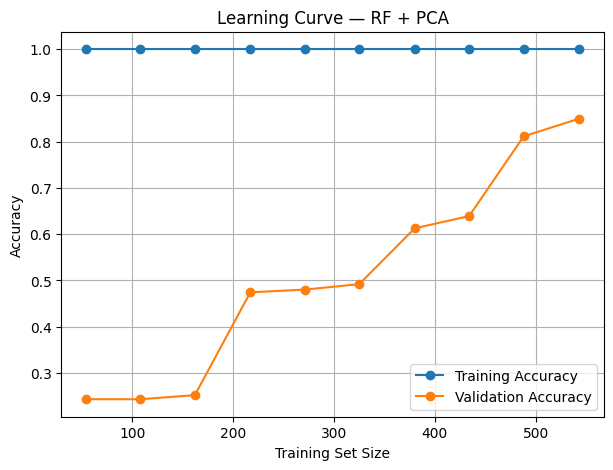

In [9]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    best_rf_pca,
    X_train_pca,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — RF + PCA")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

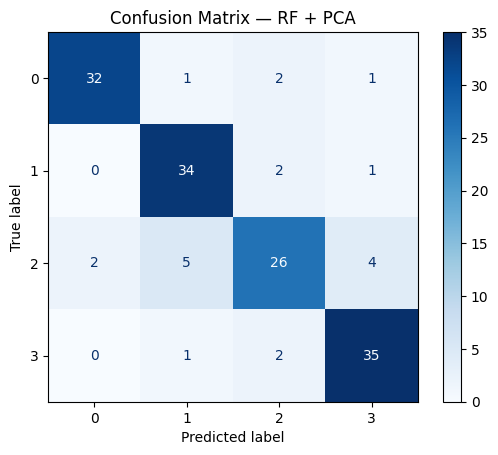

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = best_rf_pca.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — RF + PCA")
plt.show()

In [11]:
from sklearn.metrics import classification_report

y_test_pred = best_rf_pca.predict(X_test_pca)

print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.94      0.89      0.91        36
           1       0.83      0.92      0.87        37
           2       0.81      0.70      0.75        37
           3       0.85      0.92      0.89        38

    accuracy                           0.86       148
   macro avg       0.86      0.86      0.86       148
weighted avg       0.86      0.86      0.86       148



In [ ]:
import joblib

joblib.dump(best_rf_pca, "models/rf_pca_model.pkl")
print("RF saved.")

RF saved.


RF - MI

In [22]:
import numpy as np

# Labels
y_train = np.load("y_train_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

# PCA Features
X_train_mi = np.load("X_train_mi.npy")
X_val_mi   = np.load("X_val_mi.npy")
X_test_mi  = np.load("X_test_mi.npy")

Baseline

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_baseline_mi = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_baseline_mi.fit(X_train_mi, y_train)

val_pred  = rf_baseline_mi.predict(X_val_mi)
test_pred = rf_baseline_mi.predict(X_test_mi)

print("Baseline RF + MI Validation Acc:", accuracy_score(y_val, val_pred))
print("Baseline RF + MI Test Acc      :", accuracy_score(y_test, test_pred))

Baseline RF + MI Validation Acc: 0.9178082191780822
Baseline RF + MI Test Acc      : 0.8513513513513513


Parameter Tuning

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees = ExtraTreesClassifier(
    n_estimators=700,
    max_features=0.9, 
    random_state=42,
    n_jobs=-1
)

extra_trees.fit(X_train_mi, y_train)

print("ExtraTrees + MI Validation:", extra_trees.score(X_val_mi, y_val))
print("ExtraTrees + MI Test:", extra_trees.score(X_test_mi, y_test))

ExtraTrees + MI Validation: 0.910958904109589
ExtraTrees + MI Test: 0.831081081081081


In [18]:
param_grid_rf = {
    "n_estimators": [300, 500, 700],
    "max_depth": [None, 20, 40],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1],
    "max_features": [0.7, 0.9, 1.0],
    "class_weight": [None, "balanced"],
    "bootstrap": [True]
}

In [19]:
from sklearn.model_selection import GridSearchCV

grid_rf_mi = GridSearchCV(
    #RandomForestClassifier(random_state=42, n_jobs=-1),
    RandomForestClassifier( n_estimators=700,  max_features=0.9,
    max_samples=0.85,
    random_state=42,
    n_jobs=-1),
    param_grid_rf,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf_mi.fit(X_train_mi, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'bootstrap': [True], 'class_weight': [None, 'balanced'], 'max_depth': [None, 20, ...], 'max_features': [0.7, 0.9, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [20]:
print("Best Params:", grid_rf_mi.best_params_)
print("Best CV Score:", grid_rf_mi.best_score_)

best_rf_mi = grid_rf_mi.best_estimator_

Best Params: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 300}
Best CV Score: 0.8232135076252725


In [21]:
val_acc  = best_rf_mi.score(X_val_mi, y_val)
test_acc = best_rf_mi.score(X_test_mi, y_test)

print("\nTuned RF + MI Validation Accuracy:", val_acc)
print("Tuned RF + MI Test Accuracy:", test_acc)


Tuned RF + MI Validation Accuracy: 0.8904109589041096
Tuned RF + MI Test Accuracy: 0.8243243243243243


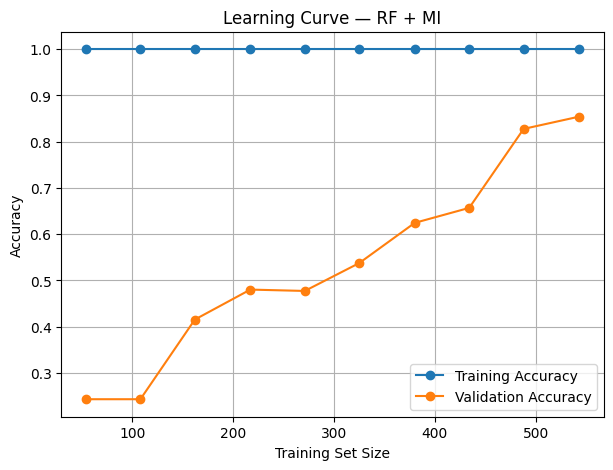

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    rf_baseline_mi,       
    X_train_mi,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — RF + MI")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

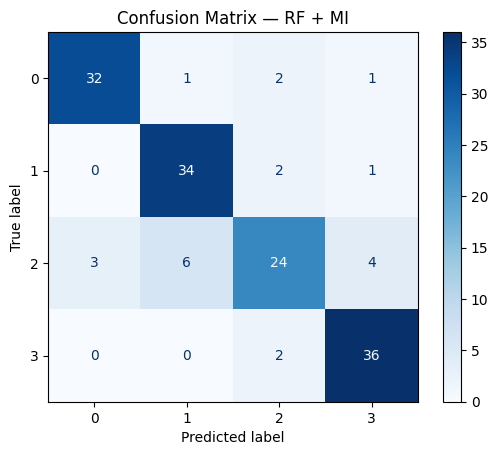

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = rf_baseline_mi.predict(X_test_mi)

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — RF + MI")
plt.show()

In [41]:
from sklearn.metrics import classification_report

y_test_pred = rf_baseline_mi.predict(X_test_mi)

print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.83      0.92      0.87        37
           2       0.80      0.65      0.72        37
           3       0.86      0.95      0.90        38

    accuracy                           0.85       148
   macro avg       0.85      0.85      0.85       148
weighted avg       0.85      0.85      0.85       148



RF - BORUTA

In [34]:
import numpy as np

# Labels
y_train = np.load("y_train_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

# PCA Features
X_train_boruta = np.load("X_train_boruta.npy")
X_val_boruta   = np.load("X_val_boruta.npy")
X_test_boruta  = np.load("X_test_boruta.npy")

Baseline

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_baseline_boruta = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_baseline_boruta.fit(X_train_boruta, y_train)

val_pred  = rf_baseline_boruta.predict(X_val_boruta)
test_pred = rf_baseline_boruta.predict(X_test_boruta)

print("Baseline RF + Boruta Validation Acc:", accuracy_score(y_val, val_pred))
print("Baseline RF + Boruta Test Acc:", accuracy_score(y_test, test_pred))

Baseline RF + Boruta Validation Acc: 0.9041095890410958
Baseline RF + Boruta Test Acc: 0.8175675675675675


Parameter Tuning

In [29]:
from sklearn.ensemble import ExtraTreesClassifier


extra_trees_boruta = ExtraTreesClassifier(
    n_estimators=1000,
    max_features=0.9,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

extra_trees_boruta.fit(X_train_boruta, y_train)

print("ExtraTrees + Boruta Validation:", extra_trees_boruta.score(X_val_boruta, y_val))
print("ExtraTrees + Boruta Test:", extra_trees_boruta.score(X_test_boruta, y_test))

ExtraTrees + Boruta Validation: 0.9041095890410958
ExtraTrees + Boruta Test: 0.8378378378378378


In [30]:
param_grid_rf_boruta = {
    "n_estimators": [300, 500, 700],
    "max_depth": [None, 20, 40],
    "max_features": [0.7, 0.9],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1],
    "bootstrap": [True],
    "class_weight": [None, "balanced"]
}

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

grid_rf_boruta = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf_boruta,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf_boruta.fit(X_train_boruta, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'bootstrap': [True], 'class_weight': [None, 'balanced'], 'max_depth': [None, 20, ...], 'max_features': [0.7, 0.9], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [32]:
print("Best Params:", grid_rf_boruta.best_params_)
print("Best CV Score:", grid_rf_boruta.best_score_)

best_rf_boruta = grid_rf_boruta.best_estimator_

Best Params: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV Score: 0.8350217864923748


In [33]:
val_acc = best_rf_boruta.score(X_val_boruta, y_val)
test_acc = best_rf_boruta.score(X_test_boruta, y_test)

print("\nTuned RF + Boruta Validation Accuracy:", val_acc)
print("Tuned RF + Boruta Test Accuracy:", test_acc)


Tuned RF + Boruta Validation Accuracy: 0.8767123287671232
Tuned RF + Boruta Test Accuracy: 0.8040540540540541


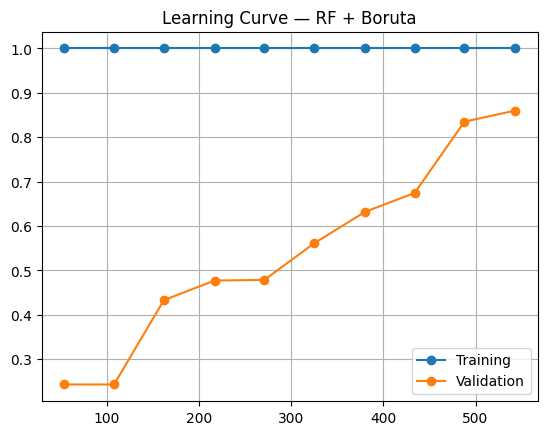

In [42]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    extra_trees_boruta,
    X_train_boruta,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker='o', label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker='o', label="Validation")
plt.title("Learning Curve — RF + Boruta")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

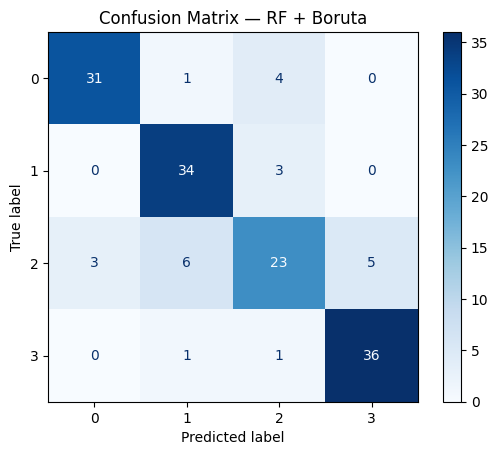

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = extra_trees_boruta.predict(X_test_boruta)

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — RF + Boruta")
plt.show()

In [44]:
from sklearn.metrics import classification_report

y_test_pred = extra_trees_boruta.predict(X_test_boruta)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.91      0.86      0.89        36
           1       0.81      0.92      0.86        37
           2       0.74      0.62      0.68        37
           3       0.88      0.95      0.91        38

    accuracy                           0.84       148
   macro avg       0.84      0.84      0.83       148
weighted avg       0.84      0.84      0.83       148

